## Homework 4: 
# Adding Missed Plots

**Ziyi Guo and Neve Zhang**

*Disclaimer*: We consulted the following AI tool to revise codes for this project.
- OpenAI. (2025). ChatGPT (Mar 26 version) [Large language model]. https://chat.openai.com/chat.

**Notes for Nissim**

Hi Nissim,

In the main notebook we submitted, we realized that we forgot to plot the misclassified images in the traditional ML models (SVM and Random Forest). However, since re-running the script alters the dataset due to data augmentation, and given that running all models takes hours while we also have other assignments to complete, we created this additional notebook to specifically re-run the SVM-related steps and include the missing plots. We feel this demonstrates our understanding of the task without needing to regenerate the entire assignment.

We hope this approach is acceptable and appreciate your understanding!

Best regards,

Neve and Ziyi

In [2]:
import os
import numpy as np
import random
from PIL import Image, ImageOps
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Set random seed
random.seed(42)

In [3]:
# Define dataset path
root_dir = r"C:\Users\ztyuu\Desktop\Spring2025\MUSA 650\musa-650-spring-2025\musa-650-guo-zhang-submissions\EuroSAT_DeepLearning"
data_dir = f"{root_dir}/2750"
image_size = (64, 64)  # Standard resize size
class_names = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])

## 1. Data Loading, Processing, and Exploration

### 1.1 Data Loading

In [4]:
images = []
labels = []

print("Loading images from each class...")
for class_index, class_name in enumerate(class_names):
    class_folder = os.path.join(data_dir, class_name)
    # List all image files in this class folder
    image_files = [f for f in os.listdir(class_folder) if f.endswith((".jpg", ".png"))]
    
    for img_file in image_files:
        img_path = os.path.join(class_folder, img_file)
        
        # Open and convert to RGB (to ensure consistent shape)
        with Image.open(img_path).convert("RGB") as img:
            # Convert to a NumPy array
            img_array = np.array(img)
            images.append(img_array)
            labels.append(class_index)

images = np.array(images)
labels = np.array(labels)

print(f"Total images loaded: {len(images)}")
print(f"Image array shape: {images.shape}")  # e.g., (n_samples, 64, 64, 3)

Loading images from each class...
Total images loaded: 27000
Image array shape: (27000, 64, 64, 3)


### 1.2 Data Exploration

Class 'AnnualCrop': 3000 samples
Class 'Forest': 3000 samples
Class 'HerbaceousVegetation': 3000 samples
Class 'Highway': 2500 samples
Class 'Industrial': 2500 samples
Class 'Pasture': 2000 samples
Class 'PermanentCrop': 2500 samples
Class 'Residential': 3000 samples
Class 'River': 2500 samples
Class 'SeaLake': 3000 samples


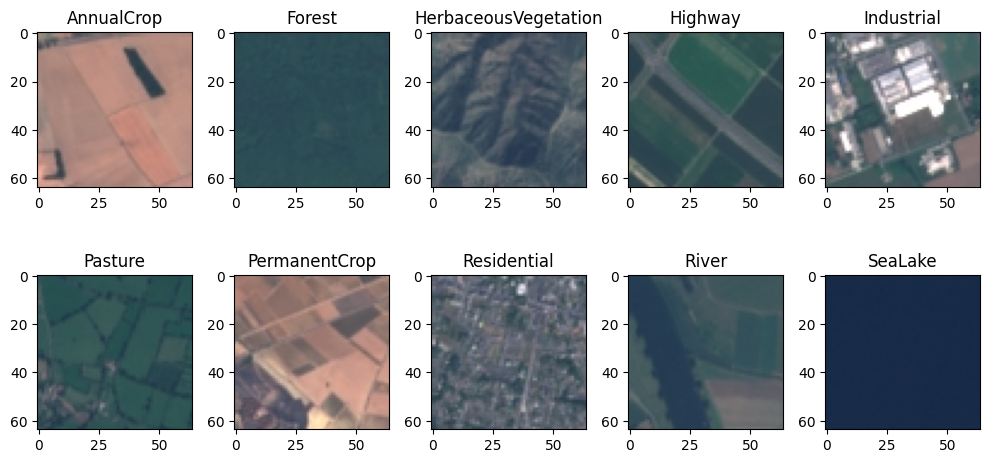

In [5]:
# Show data distribution
unique_labels, counts = np.unique(labels, return_counts=True)
for lbl, count in zip(unique_labels, counts):
    print(f"Class '{class_names[lbl]}': {count} samples")

# Show one random image from each class in a 2x5 grid
plt.figure(figsize=(10, 5))
for i, c in enumerate(np.unique(labels)): 
    plt.subplot(2, 5, i + 1)
    class_indices = np.where(labels == c)[0]

    if class_indices.size == 0:  # Check if empty
        print(f"Warning: No samples found for class {c}. Skipping...")
        continue  # Skip this iteration

    rand_idx = np.random.choice(class_indices)
    plt.imshow(images[rand_idx])
    plt.title(class_names[c])

plt.tight_layout()
plt.show()

In [6]:
# Print label-to-class mapping
print("Label to Land Use Category Mapping:")
for label in unique_labels:
    print(f"Label {label}: {class_names[label]}")

Label to Land Use Category Mapping:
Label 0: AnnualCrop
Label 1: Forest
Label 2: HerbaceousVegetation
Label 3: Highway
Label 4: Industrial
Label 5: Pasture
Label 6: PermanentCrop
Label 7: Residential
Label 8: River
Label 9: SeaLake


### 1.3 Data Augmentation

**Bonus: Before splitting the data into training and testing sets or doing any preprocessing, apply data augmentation to increase the size of the dataset, appending the new samples to the original dataset. Indicate the augmentation approach(es) that you used and the total size of the new dataset. Again, plot three random images and a histogram of the label distribution across the full dataset.**

We applied the following augmentation approaches (rotation, width shift, height shift, shear effect, and zooming up/down) to the original dataset, which doubles the sample size to 54000. This enhances sample size and to improve the model's generalizability and avoid overfitting. Then, we conducted exploratory analysis as shown below.

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,         
    width_shift_range=0.2,      
    height_shift_range=0.2,    
    shear_range=0.2,            
    zoom_range=0.2            
)

In [8]:
images_augmented = []
labels_augmented = []

num_aug_per_image = 1  

# Loop through each image in the dataset
for i in range(len(images)):
    img = images[i].reshape((1,) + images[i].shape)  # Reshape for ImageDataGenerator
    label = labels[i]

    for _ in range(num_aug_per_image):  # Generate multiple augmented versions per image
        aug_iter = datagen.flow(img, batch_size=1)  # Create augmentation iterator
        aug_img = next(aug_iter)[0].astype(np.uint8)  # Get augmented image
        images_augmented.append(aug_img)
        labels_augmented.append(label)

# Convert lists to NumPy arrays
images_augmented = np.array(images_augmented)
labels_augmented = np.array(labels_augmented)

# Combine original and augmented datasets
images_full = np.concatenate((images, images_augmented), axis=0)
labels_full = np.concatenate((labels, labels_augmented), axis=0)

# Print new dataset size
print(f"New dataset size after augmentation: {len(images_full)}")

New dataset size after augmentation: 54000


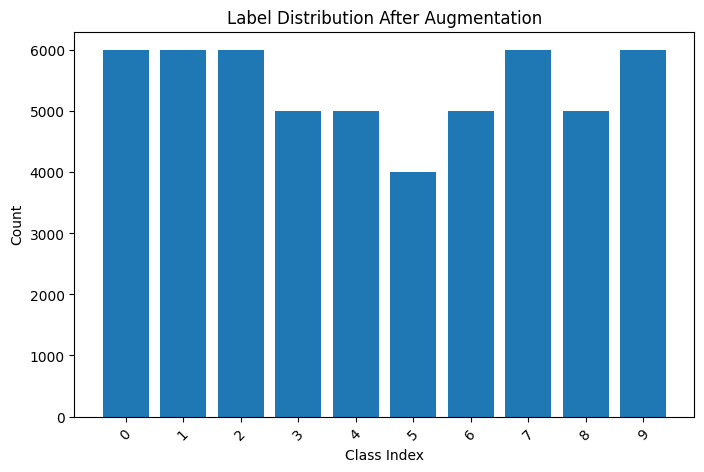

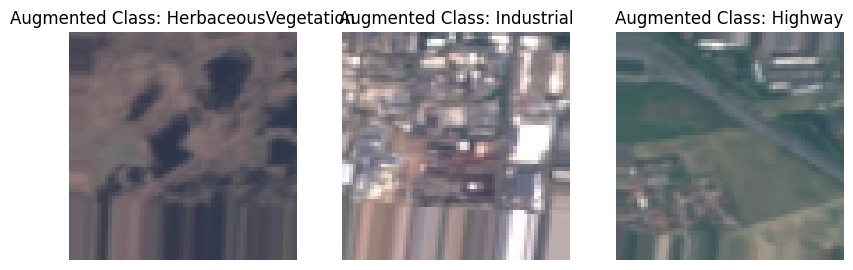

In [9]:
# Show label distribution
plt.figure(figsize=(8, 5))
plt.hist(labels_full, bins=np.arange(len(np.unique(labels_full)) + 1) - 0.5, rwidth=0.8)
plt.xticks(range(len(np.unique(labels_full))), np.unique(labels_full), rotation=45)
plt.title("Label Distribution After Augmentation")
plt.xlabel("Class Index")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 3))
for i in range(3):
    idx = np.random.randint(0, len(images_augmented))
    plt.subplot(1, 3, i + 1)
    plt.imshow(images_augmented[idx])
    
    # Get class name from the class_names list using the label index
    class_name = class_names[labels_augmented[idx]]  
    
    plt.title(f"Augmented Class: {class_name}")
    plt.axis("off")
plt.show()

### 1.4 Data Flattening

While we performed data flattening to satisfy the task required, *we did not end up using the flattened RGB images since RGB images are only involved in the CNN model development*. Essentially, the flattening process destroy spatial relationships between pixels, which are crucial for detecting edges, textures, and patterns when applying a CNN model.

In [10]:
# Flatten Images into 2D Matrix
num_samples, img_height, img_width, num_channels = images_full.shape
images_flat = images_full.reshape(num_samples, img_height * img_width * num_channels)

### 1.5 Data Splitting

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    images_flat, labels_full, test_size=0.4, stratify=labels_full, random_state=42
)

In [12]:
print(f"Flattened dataset shape: {images_flat.shape}")
print(f"Training set size: {X_train.shape}, Testing set size: {X_test.shape}")

Flattened dataset shape: (54000, 12288)
Training set size: (32400, 12288), Testing set size: (21600, 12288)


### 1.6 Create Gray-Scale Images

We created a grey-scale version of the full dataset after augmentation, then flattening them for traditional machine learning models and fully connected neural networks.

In [13]:
def convert_to_grayscale(image_array):
    """Convert an RGB image to grayscale using PIL."""
    img = Image.fromarray(image_array)  # Convert NumPy array to PIL Image
    img_gray = img.convert("L")  # Convert to grayscale
    return np.array(img_gray)  # Convert back to NumPy array

images_gray = np.array([convert_to_grayscale(img) for img in images_full])

In [14]:
# Flatten Gray-scale images
num_samples, img_height, img_width = images_gray.shape
images_gray_flat = images_gray.reshape(num_samples, img_height * img_width)

In [15]:
# Train-Test Split
X_train_gray, X_test_gray, y_train_gray, y_test_gray = train_test_split(
    images_gray_flat, labels_full, test_size=0.4, stratify=labels_full, random_state=42
)

print(f"Grayscale dataset shape: {images_gray.shape}")
print(f"Flattened grayscale dataset shape: {images_gray_flat.shape}")
print(f"Training set size: {X_train_gray.shape}, Testing set size: {X_test_gray.shape}")

Grayscale dataset shape: (54000, 64, 64)
Flattened grayscale dataset shape: (54000, 4096)
Training set size: (32400, 4096), Testing set size: (21600, 4096)


## 2. Traditional Machine-Learning

In [16]:
target_classes = ["Forest", "Residential", "Industrial"]
target_labels = [class_names.index(cls) for cls in target_classes]

# Create a boolean mask: True if y is in {Forest, Residential, Industrial}
mask = np.isin(labels_full, target_labels)

# Filter the flattened grayscale data and labels
X_3class = images_gray_flat[mask]
y_3class = labels_full[mask]

print("Filtered dataset shape:", X_3class.shape)
print("Filtered labels shape:", y_3class.shape)

Filtered dataset shape: (17000, 4096)
Filtered labels shape: (17000,)


In [17]:
# Split the filtered dataset into train/test
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(
    X_3class, 
    y_3class, 
    test_size=0.4, 
    stratify=y_3class, 
    random_state=42
)

print("3-class Training set size:", X_train_3.shape[0])
print("3-class Testing set size:", X_test_3.shape[0])

3-class Training set size: 10200
3-class Testing set size: 6800


### 2.1 Binary Support Vector Machine

In [18]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [19]:
def filter_two_classes(X, y, class_a, class_b):
    """
    Keeps only samples belonging to class_a or class_b.
    Maps class_a -> 0, class_b -> 1 for binary classification.
    """
    mask = (y == class_a) | (y == class_b)
    X_2 = X[mask]
    y_2 = y[mask].copy()
    
    # Map the labels: class_a -> 0, class_b -> 1
    y_2[y_2 == class_a] = 0
    y_2[y_2 == class_b] = 1
    return X_2, y_2

In [20]:
# Identify numeric labels for each class
forest_label = class_names.index("Forest")
residential_label = class_names.index("Residential")
industrial_label = class_names.index("Industrial")

# We'll store models and their evaluation info in dictionaries
svm_models = {}
svm_metrics = {}

#### Forest vs Residential

In [21]:
X_train_FR, y_train_FR = filter_two_classes(X_train_3, y_train_3, forest_label, residential_label)
X_test_FR, y_test_FR = filter_two_classes(X_test_3, y_test_3, forest_label, residential_label)

svm_FR = SVC(kernel='linear', probability=True, random_state=42)
svm_FR.fit(X_train_FR, y_train_FR)
y_pred_FR = svm_FR.predict(X_test_FR)

In [34]:
acc_FR = accuracy_score(y_test_FR, y_pred_FR)
cm_FR = confusion_matrix(y_test_FR, y_pred_FR)
report_FR = classification_report(y_test_FR, y_pred_FR)

y_prob_FR = svm_FR.predict_proba(X_test_FR)[:, 1]
fpr_FR, tpr_FR, _ = roc_curve(y_test_FR, y_prob_FR)
auc_FR = roc_auc_score(y_test_FR, y_prob_FR)

svm_models['FR'] = svm_FR
svm_metrics['FR'] = {
    'accuracy': acc_FR,
    'confusion_matrix': cm_FR,
    'classification_report': report_FR,
    'fpr': fpr_FR, 'tpr': tpr_FR, 'auc': auc_FR
}

#### Residential vs. Industrial

In [23]:
from sklearn.model_selection import GridSearchCV

X_train_RI, y_train_RI = filter_two_classes(X_train_3, y_train_3, residential_label, industrial_label)
X_test_RI, y_test_RI = filter_two_classes(X_test_3, y_test_3, residential_label, industrial_label)

svm_RI = SVC(kernel='linear', probability=True, random_state=42)
svm_RI = GridSearchCV(svm_RI, param_grid={}, n_jobs=-1)
svm_RI.fit(X_train_RI, y_train_RI)
y_pred_RI = svm_RI.predict(X_test_RI)

In [35]:
acc_RI = accuracy_score(y_test_RI, y_pred_RI)
cm_RI = confusion_matrix(y_test_RI, y_pred_RI)
report_RI = classification_report(y_test_RI, y_pred_RI)

y_prob_RI = svm_RI.predict_proba(X_test_RI)[:, 1]
fpr_RI, tpr_RI, _ = roc_curve(y_test_RI, y_prob_RI)
auc_RI = roc_auc_score(y_test_RI, y_prob_RI)

svm_models['RI'] = svm_RI
svm_metrics['RI'] = {
    'accuracy': acc_RI,
    'confusion_matrix': cm_RI,
    'classification_report': report_RI,
    'fpr': fpr_RI, 'tpr': tpr_RI, 'auc': auc_RI
}

#### Forest vs. Industrial

In [25]:
X_train_FI, y_train_FI = filter_two_classes(X_train_3, y_train_3, forest_label, industrial_label)
X_test_FI, y_test_FI = filter_two_classes(X_test_3, y_test_3, forest_label, industrial_label)

svm_FI = SVC(kernel='linear', probability=True, random_state=42)
svm_FI = GridSearchCV(svm_FI, param_grid={}, n_jobs=-1)
svm_FI.fit(X_train_FI, y_train_FI)
y_pred_FI = svm_FI.predict(X_test_FI)

In [36]:
acc_FI = accuracy_score(y_test_FI, y_pred_FI)
cm_FI = confusion_matrix(y_test_FI, y_pred_FI)
report_FI = classification_report(y_test_FI, y_pred_FI)

y_prob_FI = svm_FI.predict_proba(X_test_FI)[:, 1]
fpr_FI, tpr_FI, _ = roc_curve(y_test_FI, y_prob_FI)
auc_FI = roc_auc_score(y_test_FI, y_prob_FI)

svm_models['FI'] = svm_FI
svm_metrics['FI'] = {
    'accuracy': acc_FI,
    'confusion_matrix': cm_FI,
    'classification_report': report_FI,
    'fpr': fpr_FI, 'tpr': tpr_FI, 'auc': auc_FI
}

**Report the accuracy of each classifier, plot their ROC curves, calculate the AUCs, and show one image that is mis-classified by each classifier, including both the predicted label and the ground truth.**

(note the statistics changed from the main notebook due to different samples generated by data augmentation; same for other models trained in this notebook.)

The following code reports the results of each classifier, including accuracy, ROC curves, and AUCs. The SVM model classifying forest against industrial performs best, attaining nearly perfect accuracy (99.55%) and an AUC of 1.000. The SVM model classifying forest against residential also performs wel (accuracy: 94.25%, AUC: 0.9917). On the other hand, the SVM model classifying Residential against Industrial is the weakest, with significantly lower accuracy (68.59%) and a weaker AUC (0.7303), indicating poor classification performance and potential data imbalance.


=== SVM FR ===
Accuracy: 0.9425
Confusion Matrix:
 [[2378   22]
 [ 254 2146]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.99      0.95      2400
           1       0.99      0.89      0.94      2400

    accuracy                           0.94      4800
   macro avg       0.95      0.94      0.94      4800
weighted avg       0.95      0.94      0.94      4800

AUC: 0.9917

=== SVM RI ===
Accuracy: 0.6859
Confusion Matrix:
 [[1706  694]
 [ 688 1312]]
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.71      0.71      2400
           1       0.65      0.66      0.66      2000

    accuracy                           0.69      4400
   macro avg       0.68      0.68      0.68      4400
weighted avg       0.69      0.69      0.69      4400

AUC: 0.7303

=== SVM FI ===
Accuracy: 0.9955
Confusion Matrix:
 [[2400    0]
 [  20 1980]]
Classification Report:
              

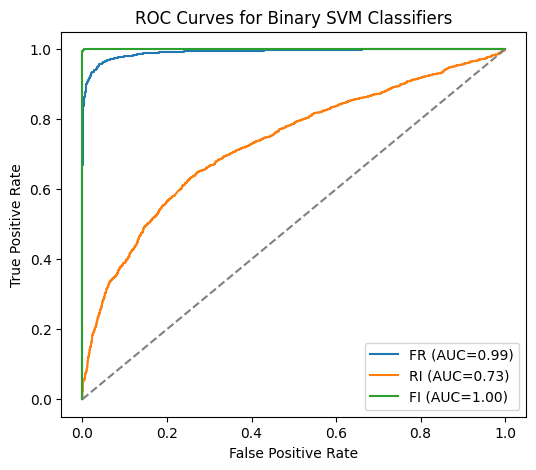

In [27]:
for pair, metrics in svm_metrics.items():
    print(f"\n=== SVM {pair} ===")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print("Confusion Matrix:\n", metrics['confusion_matrix'])
    print("Classification Report:\n", metrics['classification_report'])
    print(f"AUC: {metrics['auc']:.4f}")

# Plot ROC curves for all three
plt.figure(figsize=(6, 5))
for pair, m in svm_metrics.items():
    plt.plot(m['fpr'], m['tpr'], label=f"{pair} (AUC={m['auc']:.2f})")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Binary SVM Classifiers")
plt.legend()
plt.show()

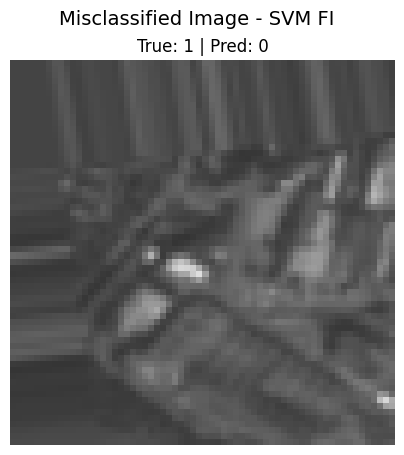

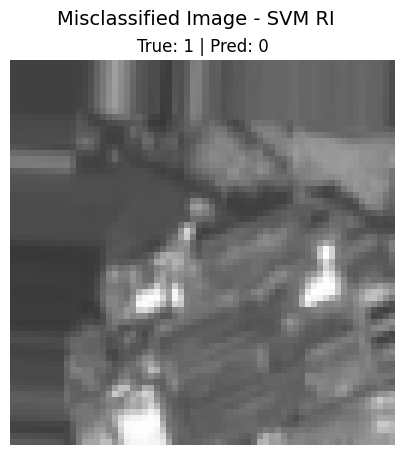

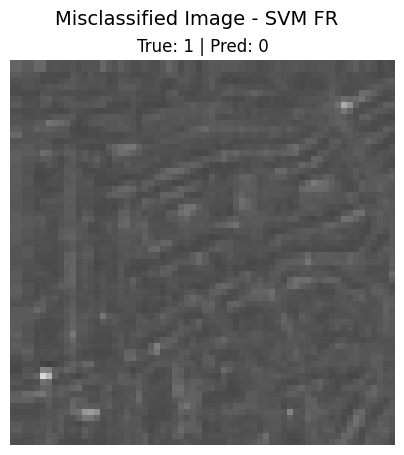

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def plot_one_misclassified_image(X_test, y_test, y_pred, title):
    """
    Plots one misclassified image.

    Parameters:
    - X_test: Test images (flattened)
    - y_test: True labels
    - y_pred: Predicted labels
    - title: Title for the plot (indicating which model is used)
    """
    # Identify misclassified indices
    misclassified_indices = np.where(y_pred != y_test)[0]

    if len(misclassified_indices) == 0:
        print(f"No misclassified images found for {title}.")
        return

    # Select the first misclassified sample
    misclass_idx = misclassified_indices[0]

    # Reshape image correctly: Handle grayscale (64x64) and RGB (64x64x3)
    img_shape = (64, 64) if X_test.shape[1] == 4096 else (64, 64, 3)
    img = X_test[misclass_idx].reshape(img_shape)

    # Convert grayscale to RGB if necessary
    if len(img_shape) == 2:
        img = np.stack([img] * 3, axis=-1)

    # Plot the misclassified image
    plt.figure(figsize=(5, 5))
    plt.imshow(img.astype(np.uint8))
    plt.title(f"True: {y_test[misclass_idx]} | Pred: {y_pred[misclass_idx]}")
    plt.axis("off")
    plt.suptitle(title, fontsize=14)
    plt.show()

# Dictionary of trained models and their test predictions
svm_models_plot = {
    "SVM FI": (X_test_FI, y_test_FI, y_pred_FI),
    "SVM RI": (X_test_RI, y_test_RI, y_pred_RI),
    "SVM FR": (X_test_FR, y_test_FR, y_pred_FR)
}

# Loop through each trained model and plot **one** misclassified image
for model_name, (X_test, y_test, y_pred) in svm_models_plot.items():
    plot_one_misclassified_image(X_test, y_test, y_pred, title=f"Misclassified Image - {model_name}")

### 2.2 Multiclass, Majority-Vote Support Vector Machine

In [37]:
from collections import Counter

def majority_vote_3classes(x, svm_FR, svm_RI, svm_FI, forest_label, residential_label, industrial_label):
    """
    For a single sample x, get votes from FR, RI, FI classifiers.
    Return the final predicted class label (forest_label, residential_label, or industrial_label).
    """
    # FR: 0 -> forest, 1 -> residential
    vote_FR = svm_FR.predict([x])[0]
    # RI: 0 -> residential, 1 -> industrial
    vote_RI = svm_RI.predict([x])[0]
    # FI: 0 -> forest, 1 -> industrial
    vote_FI = svm_FI.predict([x])[0]
    
    votes = []
    # Convert each binary vote back to the original label
    # FR
    if vote_FR == 0:
        votes.append(forest_label)
    else:
        votes.append(residential_label)
    # RI
    if vote_RI == 0:
        votes.append(residential_label)
    else:
        votes.append(industrial_label)
    # FI
    if vote_FI == 0:
        votes.append(forest_label)
    else:
        votes.append(industrial_label)
    
    # Tally the votes
    most_common = Counter(votes).most_common()
    # most_common is like [(label1, count1), (label2, count2), ...]
    # Return the label with the highest vote count
    return most_common[0][0]

# Apply majority vote to the entire 3-class test set
y_pred_mv = []
for x in X_test_3:
    pred_label = majority_vote_3classes(
        x, svm_models['FR'], svm_models['RI'], svm_models['FI'], 
        forest_label, residential_label, industrial_label
    )
    y_pred_mv.append(pred_label)

y_pred_mv = np.array(y_pred_mv)

**Again, calculate the accuracy, ROC, and AUC, and show a mis-classified image from each class, including both the predicted label and the ground truth.**

The multiclass, majority-vote SVM model outputs the following performance statistics (accuracy, ROC and AUC), the overall accuracy is 0.7704, and the overall AUC is 0.825. Class-Specific AUC wise, the model classifies forest instances with the highest accuracy (Forest AUC = 0.964), followed by Residential (AUC = 0.747) and Industrial (AUC = 0.763). 

In [38]:
# Evaluate
mv_accuracy = accuracy_score(y_test_3, y_pred_mv)
mv_cm = confusion_matrix(y_test_3, y_pred_mv, labels=target_labels)
mv_report = classification_report(y_test_3, y_pred_mv, target_names=target_classes)

print("\n=== Multiclass SVM (Majority Vote) ===")
print(f"Accuracy: {mv_accuracy:.4f}")
print("Confusion Matrix (rows=true, cols=pred):\n", mv_cm)
print("Classification Report:\n", mv_report)


=== Multiclass SVM (Majority Vote) ===
Accuracy: 0.7704
Confusion Matrix (rows=true, cols=pred):
 [[2378   22    0]
 [ 239 1555  606]
 [  35  659 1306]]
Classification Report:
               precision    recall  f1-score   support

      Forest       0.90      0.99      0.94      2400
 Residential       0.68      0.65      0.67      2000
  Industrial       0.70      0.65      0.67      2400

    accuracy                           0.77      6800
   macro avg       0.76      0.76      0.76      6800
weighted avg       0.76      0.77      0.77      6800



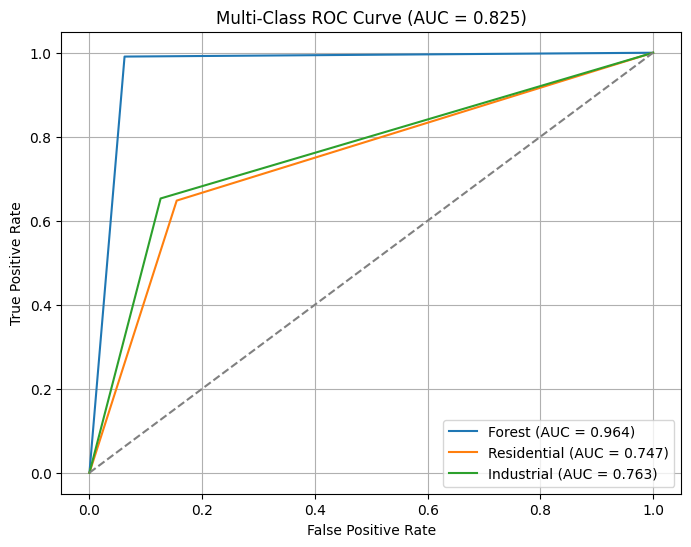

In [40]:
from sklearn.preprocessing import label_binarize

# One-hot encode the labels for multi-class ROC computation
y_test_bin = label_binarize(y_test_3, classes=target_labels)

# Binarize the predicted labels
y_pred_bin = label_binarize(y_pred_mv, classes=target_labels)

# Compute AUC Score for each class and the macro average
mv_auc = roc_auc_score(y_test_bin, y_pred_bin, average="macro")

# Compute ROC curves for each class
fpr, tpr = {}, {}
for i in range(len(target_labels)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])

plt.figure(figsize=(8, 6))
for i, label in enumerate(target_classes):
    plt.plot(fpr[i], tpr[i], label=f"{label} (AUC = {roc_auc_score(y_test_bin[:, i], y_pred_bin[:, i]):.3f})")

# Plot settings
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Multi-Class ROC Curve (AUC = {mv_auc:.3f})")
plt.legend(loc="lower right")
plt.grid()
plt.show()

A misclassified image for each class is shown below (Industrial (4), Residential (7), and Forest (1)).

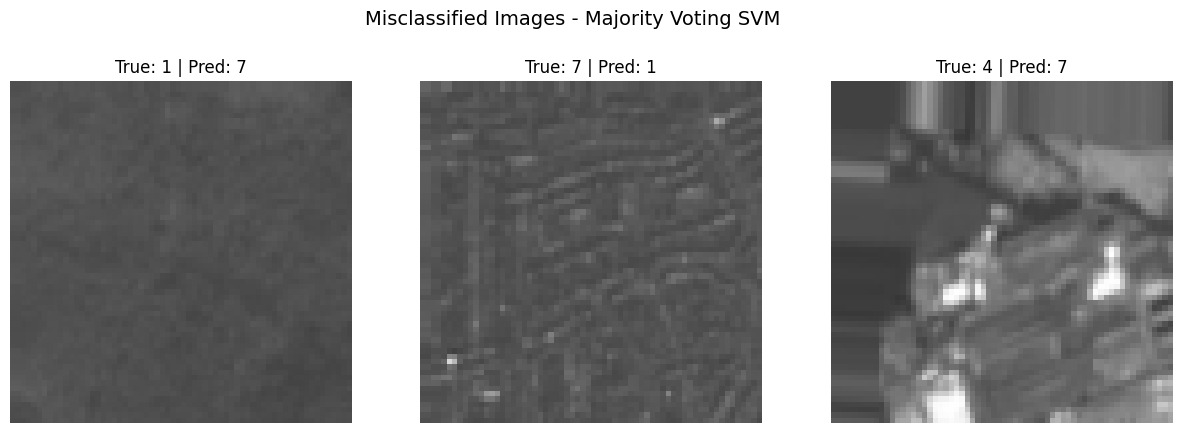

In [42]:
def plot_misclassified_images_multiclass(X_test, y_test, y_pred, class_labels, title):
    """
    Plots one misclassified image from each class.

    Parameters:
    - X_test: Test images (flattened)
    - y_test: True labels
    - y_pred: Predicted labels
    - class_labels: List of all possible class labels
    - title: Title for the plot
    """
    # Identify misclassified indices
    misclassified_indices = np.where(y_pred != y_test)[0]

    # Dictionary to store misclassified images for each class
    misclassified_samples = {label: None for label in class_labels}

    # Find one misclassified image per class
    for idx in misclassified_indices:
        true_label = y_test[idx]
        pred_label = y_pred[idx]

        if misclassified_samples[true_label] is None: 
            misclassified_samples[true_label] = idx

        if all(misclassified_samples.values()):
            break

    # Plot the misclassified images
    fig, axes = plt.subplots(1, len(class_labels), figsize=(15, 5))
    fig.suptitle(title, fontsize=14)

    for i, class_label in enumerate(class_labels):
        idx = misclassified_samples[class_label]
        if idx is not None:
            img_shape = (64, 64) if X_test.shape[1] == 4096 else (64, 64, 3)
            img = X_test[idx].reshape(img_shape)

            if len(img_shape) == 2:
                img = np.stack([img] * 3, axis=-1)

            axes[i].imshow(img.astype(np.uint8))
            axes[i].set_title(f"True: {y_test[idx]} | Pred: {y_pred[idx]}")
            axes[i].axis("off")
        else:
            axes[i].set_title(f"No misclassified {class_label}")
            axes[i].axis("off")

    plt.show()

# Define all class labels
all_3_labels = [forest_label, residential_label, industrial_label]

# Plot misclassified images for the Majority Voting SVM model
plot_misclassified_images_multiclass(X_test_3, y_test_3, y_pred_mv, all_3_labels, title="Misclassified Images - Majority Voting SVM")


### 2.3 Multiclass Random Forest

In [43]:
from sklearn.ensemble import RandomForestClassifier
import random

**Report the accuracy, plot the confusion matrix, and print a mis-classified image from each class, including both the predicted label and the ground truth.**

The Random Forest model achieves an overall accuracy of 0.9212, demonstrating strong performance in predicting the three land cover types. The confusion matrix is shown as below. 

In [44]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_3, y_train_3)
y_pred_rf = rf.predict(X_test_3)

rf_accuracy = accuracy_score(y_test_3, y_pred_rf)
rf_cm = confusion_matrix(y_test_3, y_pred_rf, labels=target_labels)
rf_report = classification_report(y_test_3, y_pred_rf, target_names=target_classes)

print("\n=== Random Forest (3-class) ===")
print(f"Accuracy: {rf_accuracy:.4f}")
print("Confusion Matrix (rows=true, cols=pred):\n", rf_cm)
print("Classification Report:\n", rf_report)


=== Random Forest (3-class) ===
Accuracy: 0.9212
Confusion Matrix (rows=true, cols=pred):
 [[2359   41    0]
 [  26 2108  266]
 [   0  203 1797]]
Classification Report:
               precision    recall  f1-score   support

      Forest       0.99      0.98      0.99      2400
 Residential       0.87      0.90      0.88      2000
  Industrial       0.90      0.88      0.89      2400

    accuracy                           0.92      6800
   macro avg       0.92      0.92      0.92      6800
weighted avg       0.92      0.92      0.92      6800



However, some misclassifications remain. For instance, an Industrial sample (index 1310) was misclassified as Residential, highlighting potential challenges in distinguishing between these two classes since they are both artificial constructs.

The plots further visualize a misclassified image for each class is shown below (Industrial (4), Residential (7), and Forest (1)).

In [45]:
misclassified_idx = np.where(y_pred_rf != y_test_3)[0]
if len(misclassified_idx) > 0:
    # Pick one misclassified example at random
    idx = random.choice(misclassified_idx.tolist())
    print(f"Misclassified sample index: {idx}")
    print(f"True label: {class_names[y_test_3[idx]]}, Predicted label: {class_names[y_pred_rf[idx]]}")

Misclassified sample index: 1310
True label: Industrial, Predicted label: Residential


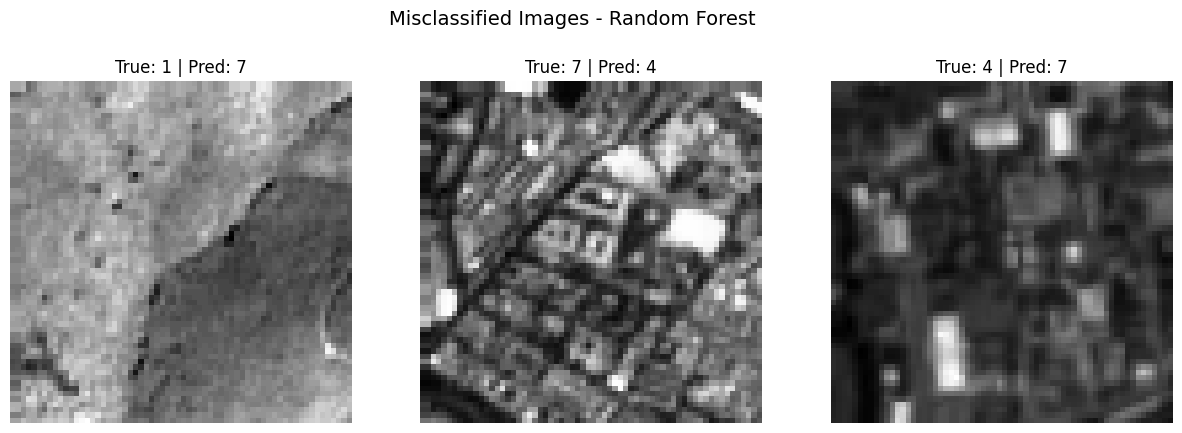

In [46]:
def plot_misclassified_images_rf(X_test, y_test, y_pred, class_labels, title):
    """
    Plots one misclassified image from each class.

    Parameters:
    - X_test: Test images (flattened)
    - y_test: True labels
    - y_pred: Predicted labels
    - class_labels: List of all possible class labels
    - title: Title for the plot
    """
    # Identify misclassified indices
    misclassified_indices = np.where(y_pred != y_test)[0]

    # Dictionary to store misclassified images for each class
    misclassified_samples = {label: None for label in class_labels}

    # Find one misclassified image per class
    for idx in misclassified_indices:
        true_label = y_test[idx]
        pred_label = y_pred[idx]

        if misclassified_samples[true_label] is None:  # Only store the first one found
            misclassified_samples[true_label] = idx

        if all(misclassified_samples.values()):  # Stop if we found one for each class
            break

    # Plot the misclassified images
    fig, axes = plt.subplots(1, len(class_labels), figsize=(15, 5))
    fig.suptitle(title, fontsize=14)

    for i, class_label in enumerate(class_labels):
        idx = misclassified_samples[class_label]
        if idx is not None:
            # Reshape back to grayscale format (64, 64)
            img = X_test[idx].reshape(64, 64)

            axes[i].imshow(img, cmap="gray")  # Set colormap to grayscale
            axes[i].set_title(f"True: {y_test[idx]} | Pred: {y_pred[idx]}")
            axes[i].axis("off")
        else:
            axes[i].set_title(f"No misclassified {class_label}")
            axes[i].axis("off")

    plt.show()

# Define all class labels
all_3_labels = [forest_label, residential_label, industrial_label]

# Plot misclassified images for the Random Forest model
plot_misclassified_images_rf(X_test_3, y_test_3, y_pred_rf, all_3_labels, title="Misclassified Images - Random Forest")

**Finished Making-Up Missed Work!!**

Please refer to the main notebook for the Deep Learning Approaches. Thank you!